# Test Fine-tuning Results
Test the fine-tuned LIANet model on PASTIS T31TFJ validation fold 2

In [71]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from rasterio.windows import Window
from utils import s2_to_rgb, _preprocess_S2
# Add src to path
sys.path.insert(0, '/home/user/src')
import rasterio as rio
from datasets import PASTIS
from models.models_finetune import UNet, MicroUNet
from utils import _preprocess_S2
from settings import TOP_DIR
from datetime import datetime

# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [72]:
# Configuration
TASK = "PASTIS_T31TFM"
S2_TILE = "T31TFM"
LABELS_PATH = "masks/PASTIS"
BATCH_SIZE = 1
NUM_CLASSES = 20  # PASTIS segmentation

# Checkpoint path
CKPT_PATH_PRETRAIN = "/home/user/results_shared/fourier_learned_4regions/2026-03-18_19-06-01/model_checkpoints/latest_validation_checkpoint.pt"
CKPT_PATH_FINETUNE = "/home/user/results_local/finetuning_results/PASTIS_T30UXV/LIANet_valFolds3/2026-04-01_13-10-03/last.pt"
CKPT_PATH_LOCAL_FINETUNE = "/home/user/results_local/finetuning_results/PASTIS_T31TFM/LIANet_valFolds3/2026-03-28_01-07-09/last.pt"



In [73]:
# Load model from checkpoint
from asyncio import Handle
import json
from models.models_finetune import DownstreamModel
from models.LIANet import LIANetLight
import omegaconf, hydra

pretrained_model_path = "/home/user/results_shared/fourier_learned_4regions/2026-03-18_19-06-01"


config_path = f"{pretrained_model_path}/used_parameters.json"
raw_cfg = omegaconf.OmegaConf.load(config_path)
resolved_dict = omegaconf.OmegaConf.to_container(raw_cfg, resolve=True)
config = omegaconf.OmegaConf.create(resolved_dict)

model_pretrain = hydra.utils.instantiate(config.model)
ckpt = torch.load(CKPT_PATH_PRETRAIN, map_location=device)
sd = ckpt["model_state_dict"]
if all(k.startswith("module.") for k in sd.keys()):
    sd = {k[len("module."):]: v for k, v in sd.items()}
model_pretrain.load_state_dict(sd, strict=False)
model_pretrain = model_pretrain.to(device)
model_pretrain.eval()
print("✓ Model loaded successfully")

# # Get config from checkpoint directory
finetune_config_path = os.path.join(os.path.dirname(CKPT_PATH_FINETUNE), "config.json")
if os.path.exists(finetune_config_path):
    with open(finetune_config_path, 'r') as f:
        config = json.load(f)
    model_type = config.get("model_type", "replace_final_block")


# Create DownstreamModel instance - CR finetuning
print(f"Loading DownstreamModel with adaptation strategy '{model_type}'...")
model_finetune = DownstreamModel(
    model_path=pretrained_model_path,
    checkpoint_path_relative="model_checkpoints/latest_validation_checkpoint.pt",
    adaption_strategy=model_type,
    num_classes=NUM_CLASSES,
    activation="none"
)

checkpoint = torch.load(CKPT_PATH_FINETUNE, map_location=device)
state_dict = checkpoint["model_state_dict"]
if state_dict and all(k.startswith("module.") for k in state_dict.keys()):
    state_dict = {k[len("module."):]: v for k, v in state_dict.items()}

model_finetune.load_state_dict(state_dict, strict=True)
model_finetune = model_finetune.to(device)
model_finetune.eval()
print("✓ Model loaded successfully")


# Create DownstreamModel instance - Local finetuning
model_local_finetune = DownstreamModel(
    model_path=pretrained_model_path,
    checkpoint_path_relative="model_checkpoints/latest_validation_checkpoint.pt",
    adaption_strategy=model_type,
    num_classes=NUM_CLASSES,
    activation="none"
)
checkpoint_local = torch.load(CKPT_PATH_LOCAL_FINETUNE, map_location=device)
state_dict_local = checkpoint_local["model_state_dict"]
if state_dict_local and all(k.startswith("module.") for k in state_dict_local.keys()):
    state_dict_local = {k[len("module."):]: v for k, v in state_dict_local.items()}
model_local_finetune.load_state_dict(state_dict_local, strict=True)
model_local_finetune = model_local_finetune.to(device)
model_local_finetune.eval()
print("✓ Local finetuned model loaded successfully")

✓ Model loaded successfully
Loading DownstreamModel with adaptation strategy 'replace_final_block'...
LIANetLight(
  (encoder): HashTableEncoder2D()
  (time_encoder): LearnedFourierTimeEncoder1D(
    (proj): Linear(in_features=16, out_features=1664, bias=True)
  )
  (preproj): Conv2d(1664, 128, kernel_size=(1, 1), stride=(1, 1))
  (light_head): LiteCNNHead(
    (stem): Sequential(
      (0): Conv2d(128, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): GroupNorm(16, 256, eps=1e-05, affine=True)
      (2): GELU(approximate='none')
    )
    (blocks): Sequential(
      (0): ConvResBlock(
        (block): Sequential(
          (0): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): GroupNorm(16, 256, eps=1e-05, affine=True)
          (2): GELU(approximate='none')
          (3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (4): GroupNorm(16, 256, eps=1e-05, affine=True)
        )
        (

In [88]:
from settings import *

TASK = "PASTIS_T31TFM"


VAL_FOLDS = [2]  # Fold 3 for validation

# print(TOP_DIR, s2_tiles[TASK], labels[TASK], VAL_FOLDS)
val_dataset = PASTIS(
    top_dir=TOP_DIR[TASK],
    s2_tiles=s2_tiles[TASK],
    labels=labels[TASK],
    train_val_key='val',
    val_folds=VAL_FOLDS,
    )



Building val image label pairs: 100%|██████████| 18/18 [00:48<00:00,  2.68s/it]

Found 2610 samples for val with >0% burned area


In [89]:
from matplotlib.colors import ListedColormap
colors = [
    (0, 0, 0),
    (0.6823529411764706, 0.7803921568627451, 0.9098039215686274),
    (1.0, 0.4980392156862745, 0.054901960784313725),
    (1.0, 0.7333333333333333, 0.47058823529411764),
    (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
    (0.596078431372549, 0.8745098039215686, 0.5411764705882353),
    (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
    (1.0, 0.596078431372549, 0.5882352941176471),
    (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
    (0.7725490196078432, 0.6901960784313725, 0.8352941176470589),
    (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
    (0.7686274509803922, 0.611764705882353, 0.5803921568627451),
    (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
    (0.9686274509803922, 0.7137254901960784, 0.8235294117647058),
    (0.4980392156862745, 0.4980392156862745, 0.4980392156862745),
    (0.7803921568627451, 0.7803921568627451, 0.7803921568627451),
    (0.7372549019607844, 0.7411764705882353, 0.13333333333333333),
    (0.8588235294117647, 0.8588235294117647, 0.5529411764705883),
    (0.09019607843137255, 0.7450980392156863, 0.8117647058823529),
    (1, 1, 1),
]
vvmin, vvmax = 0, 19


cmap = ListedColormap(colors)

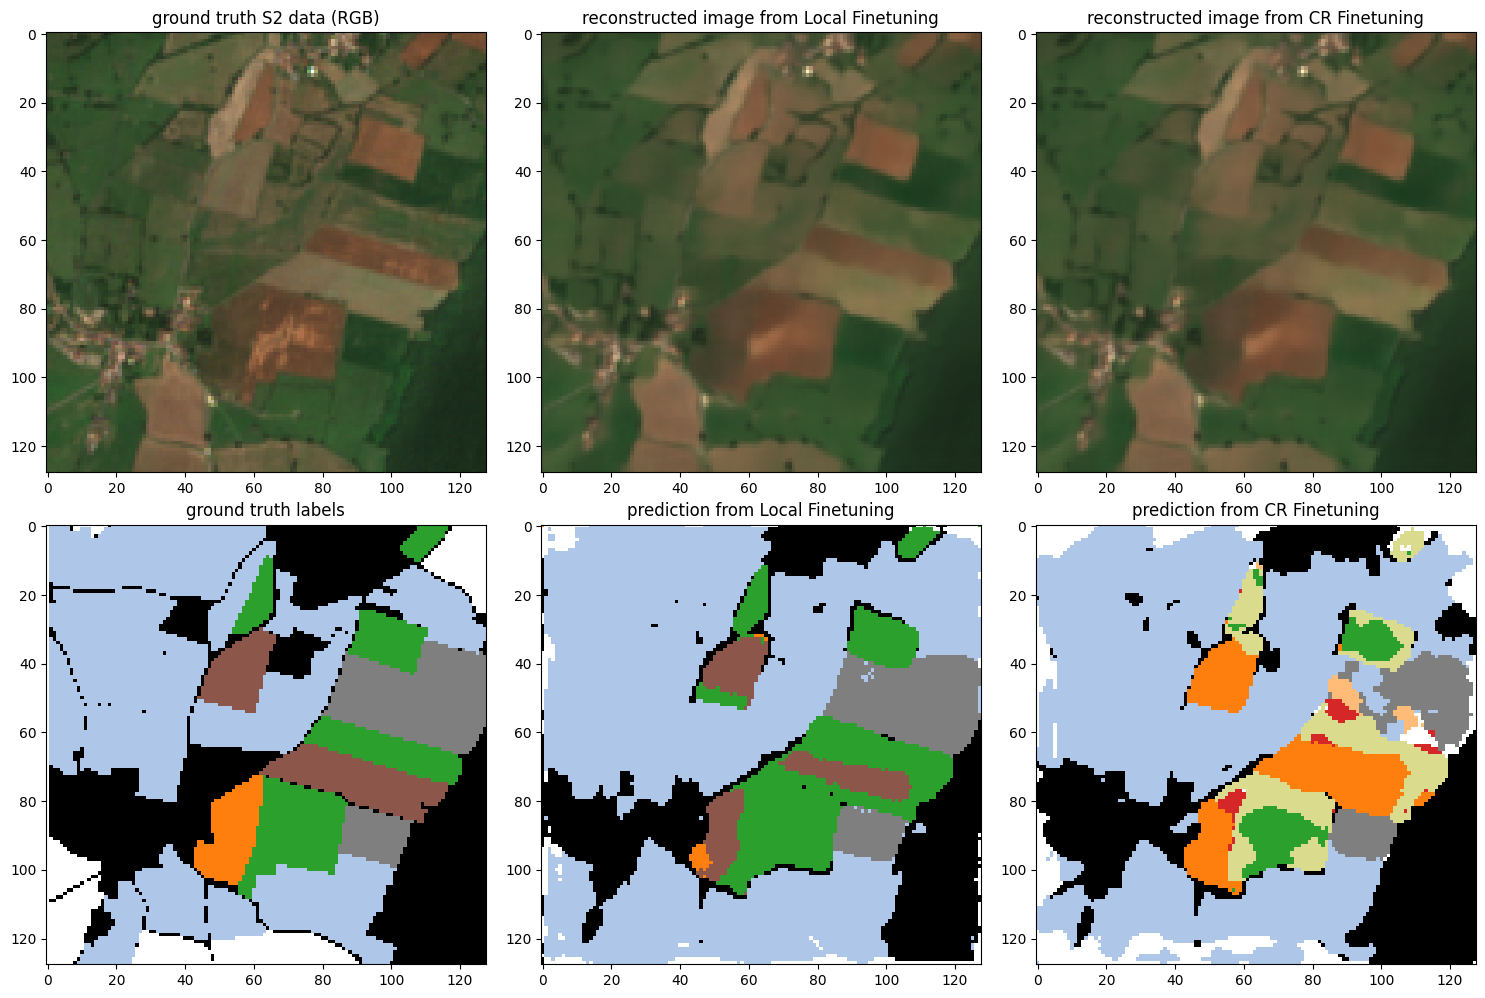

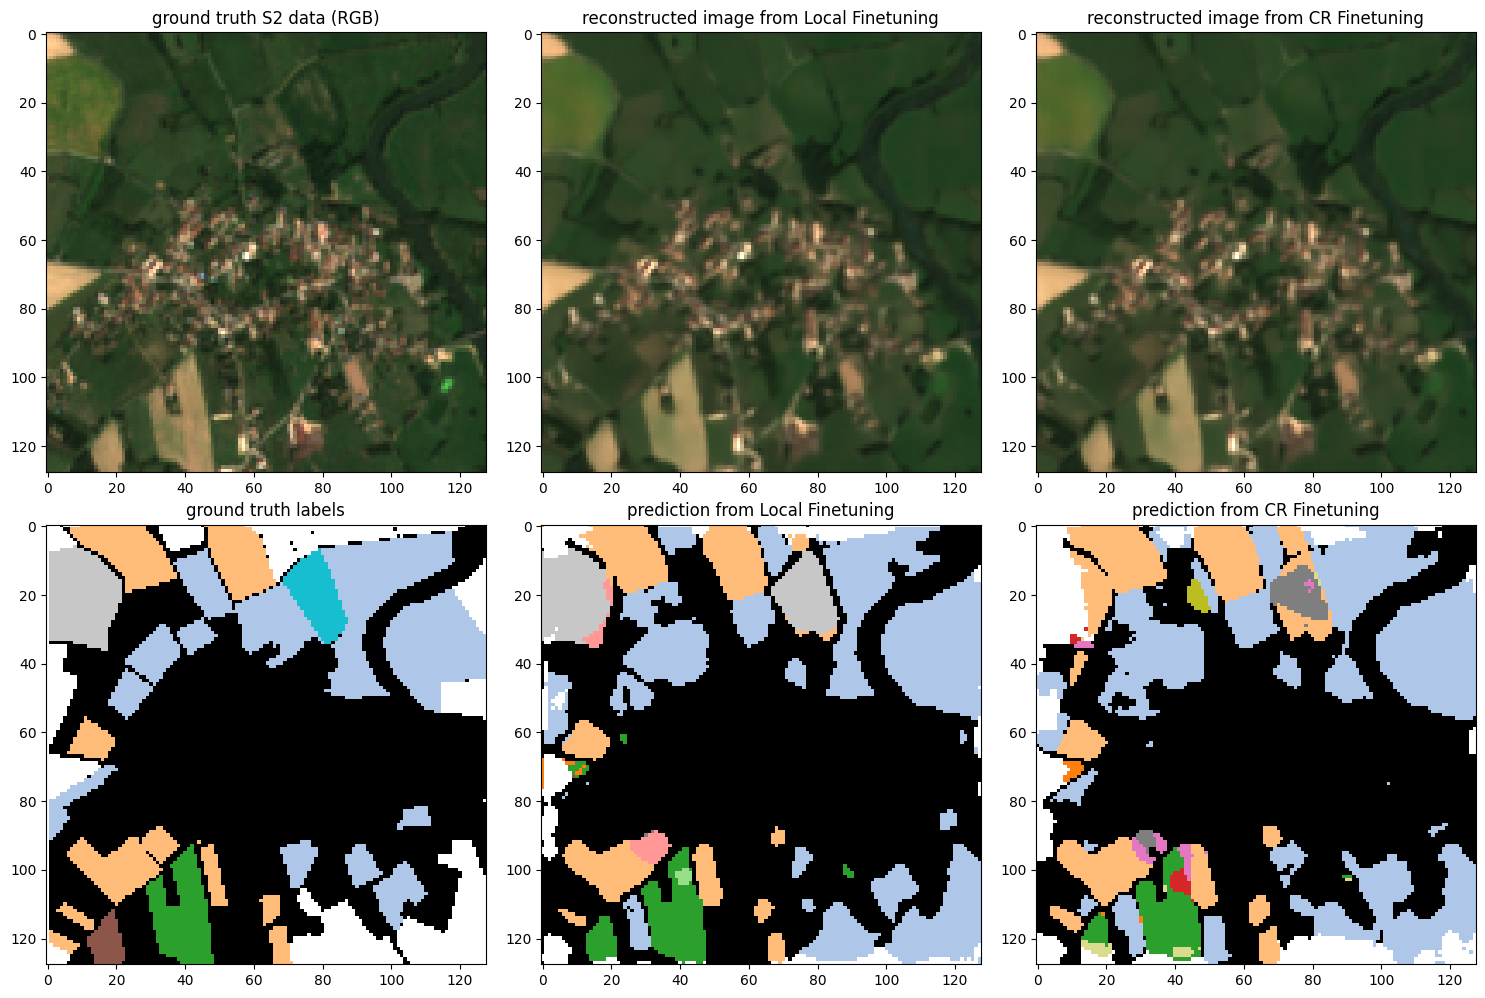

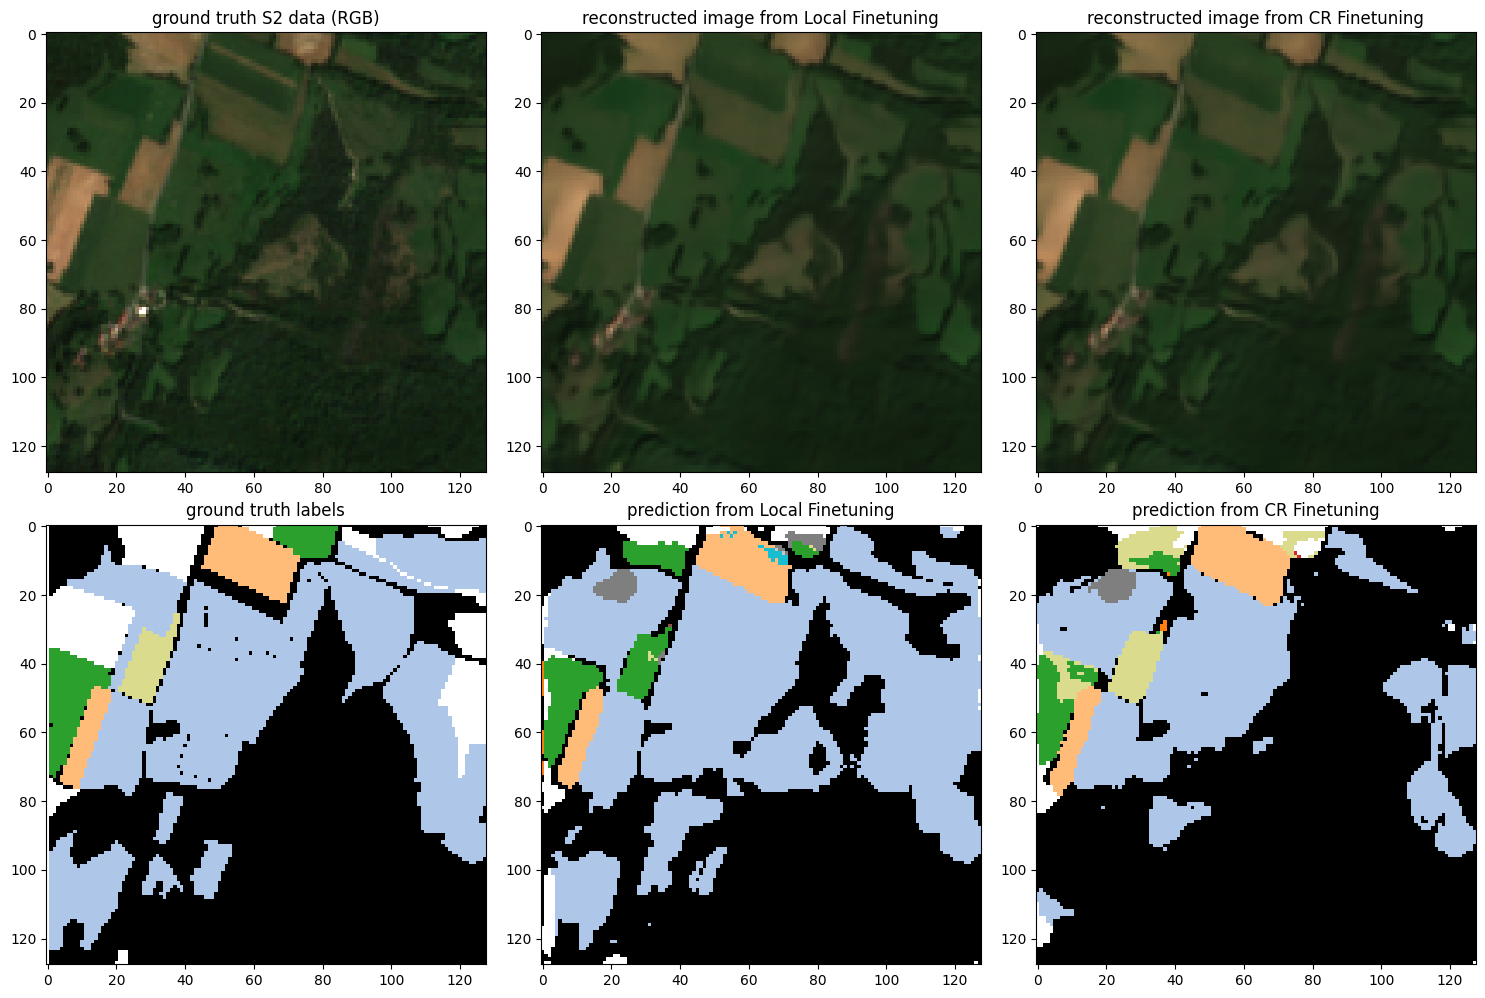

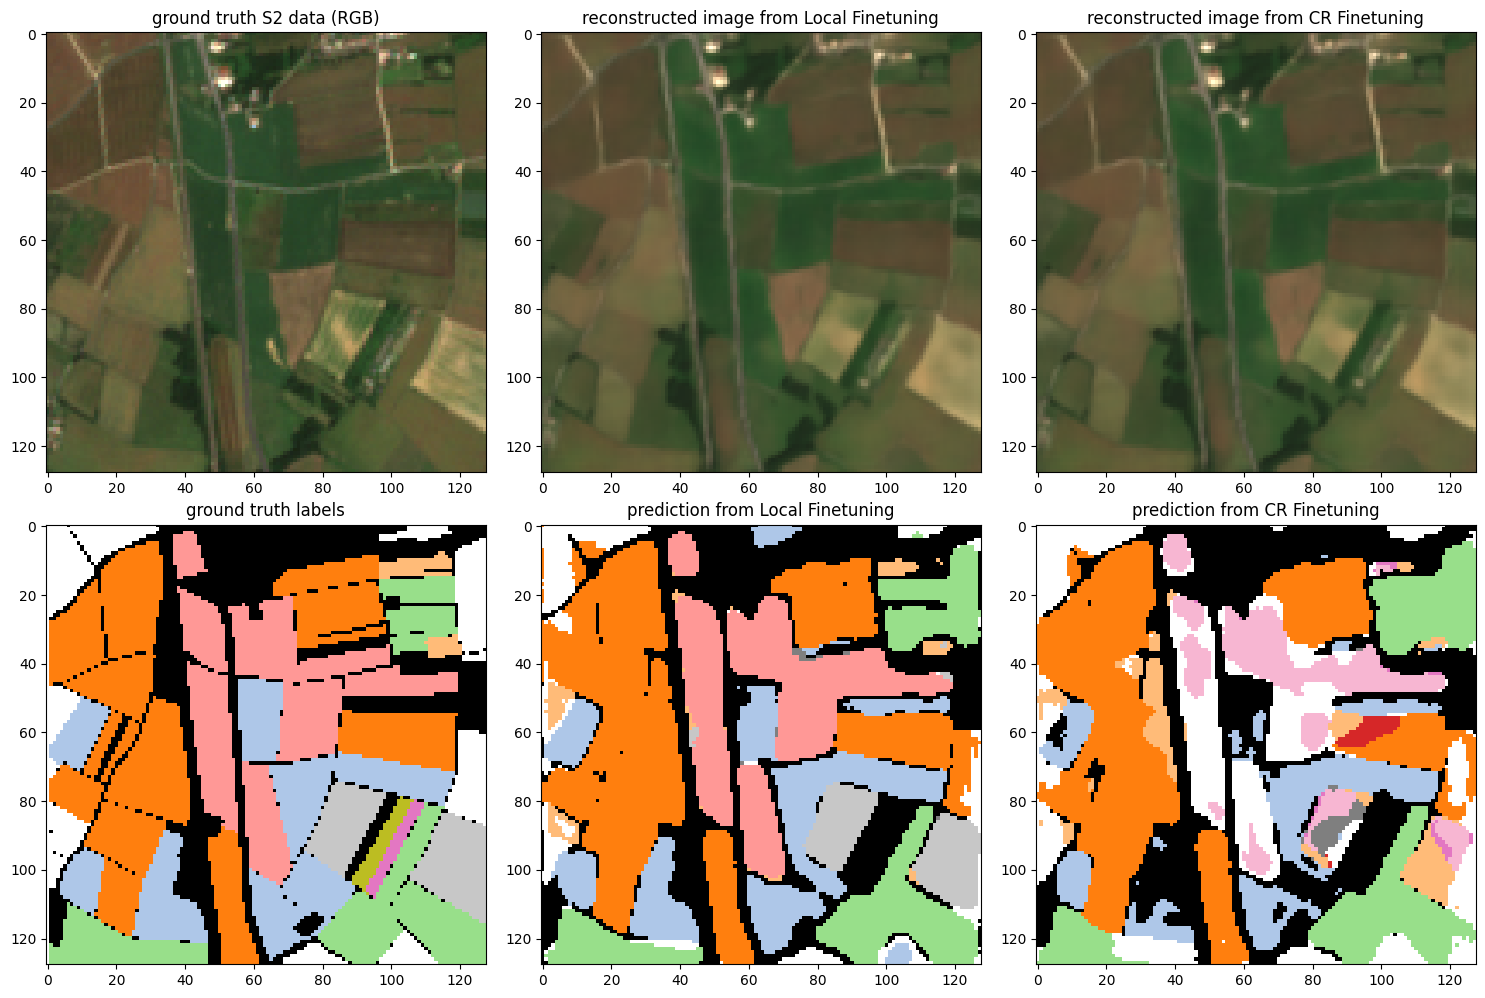

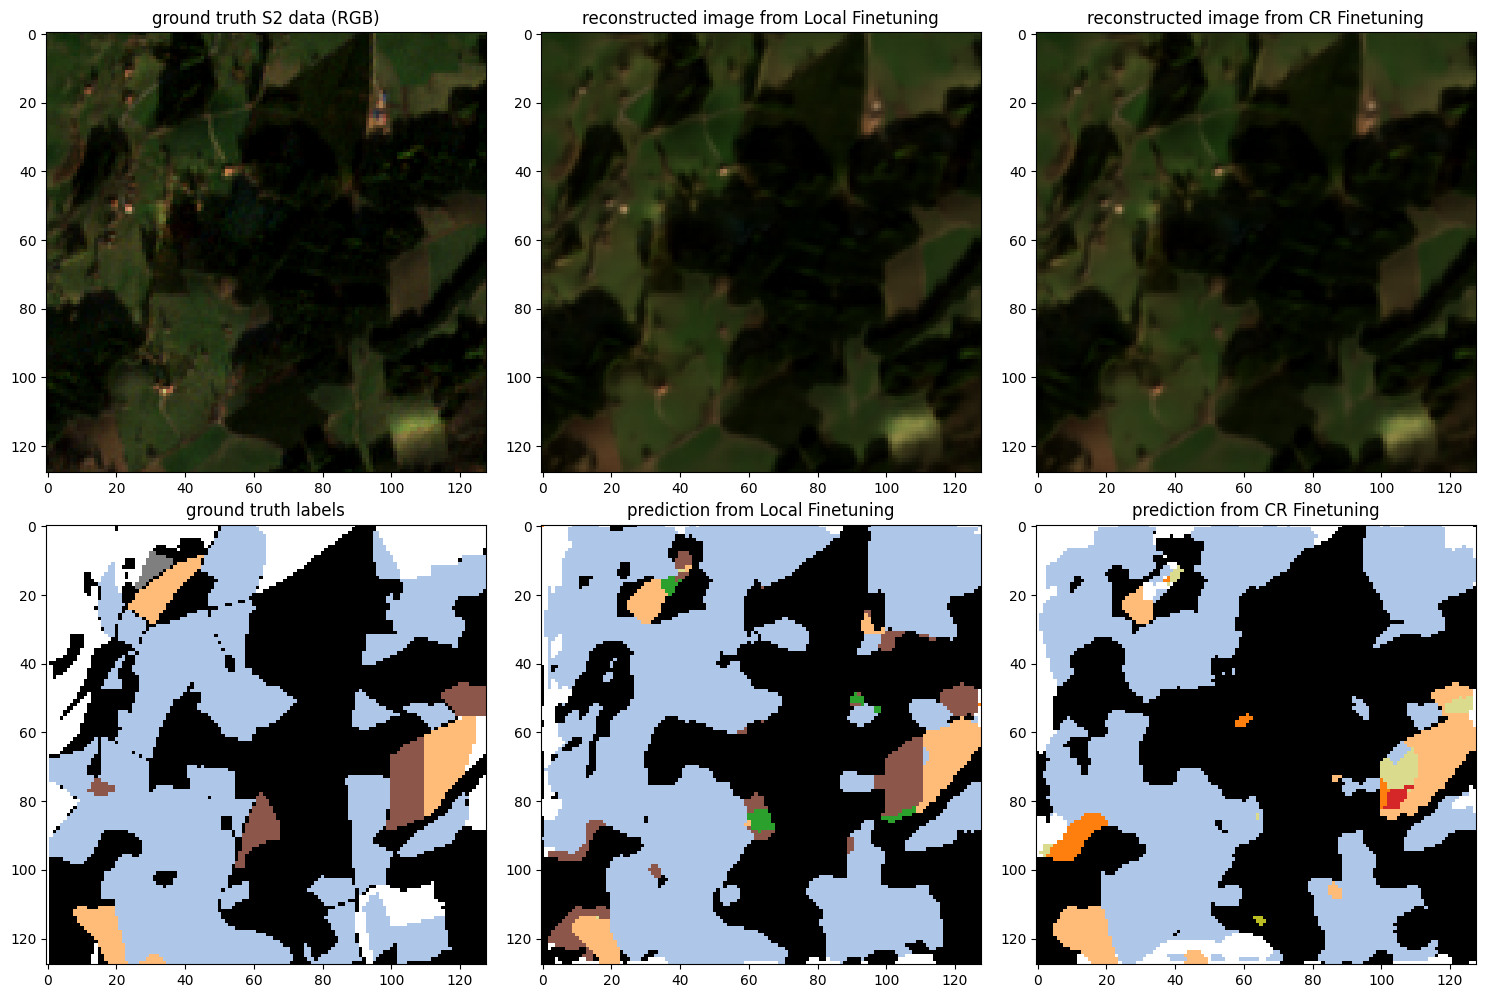

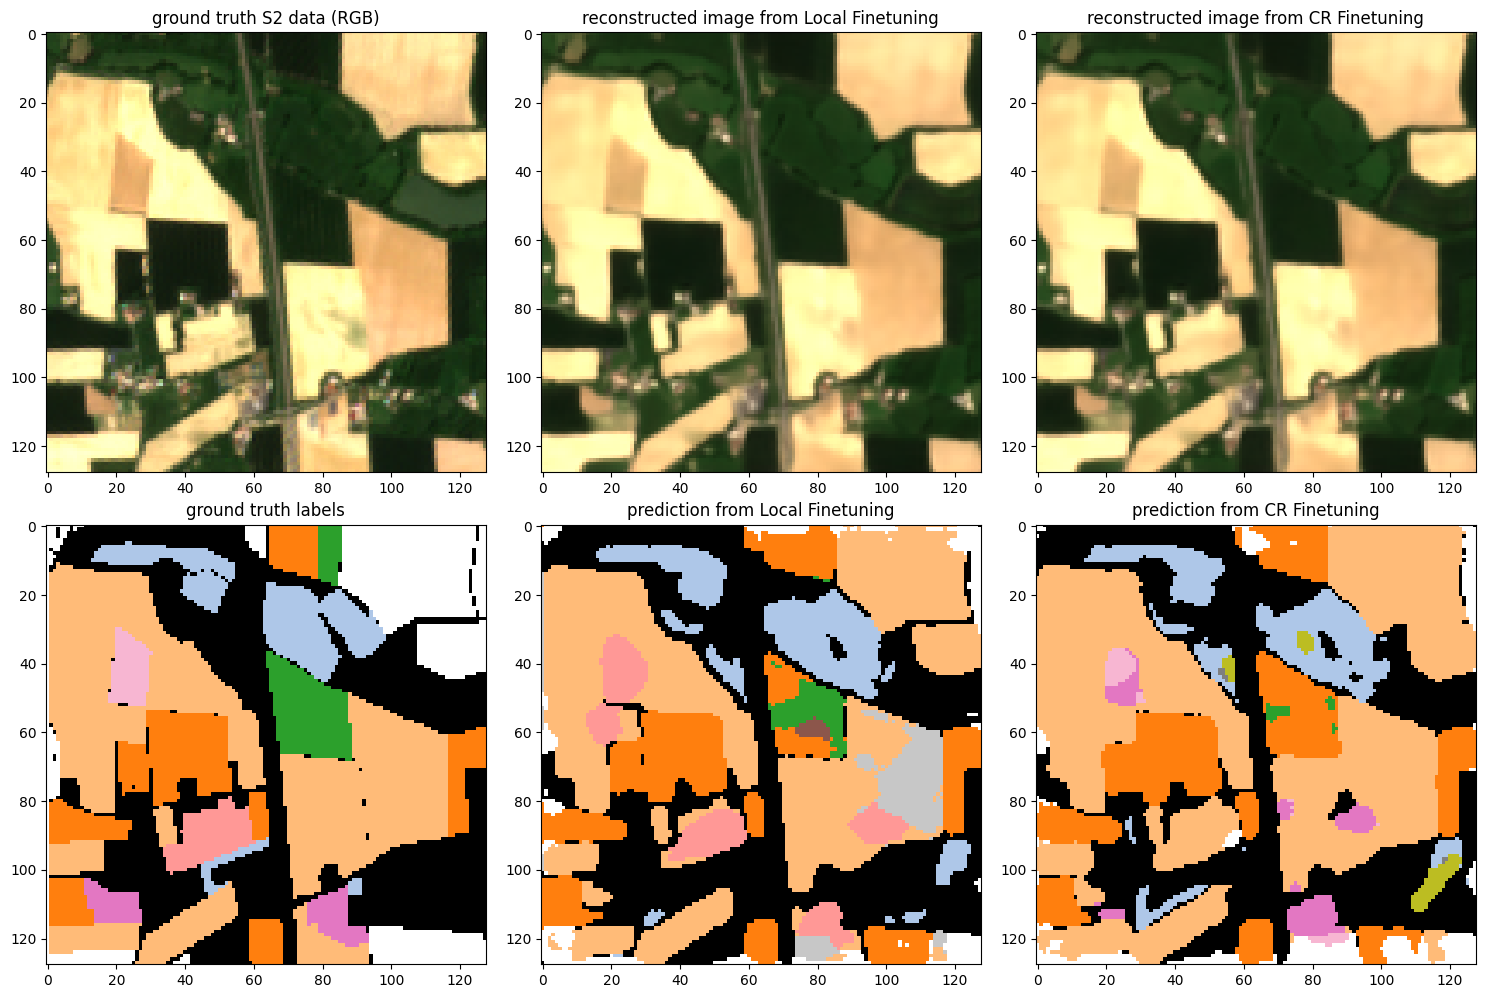

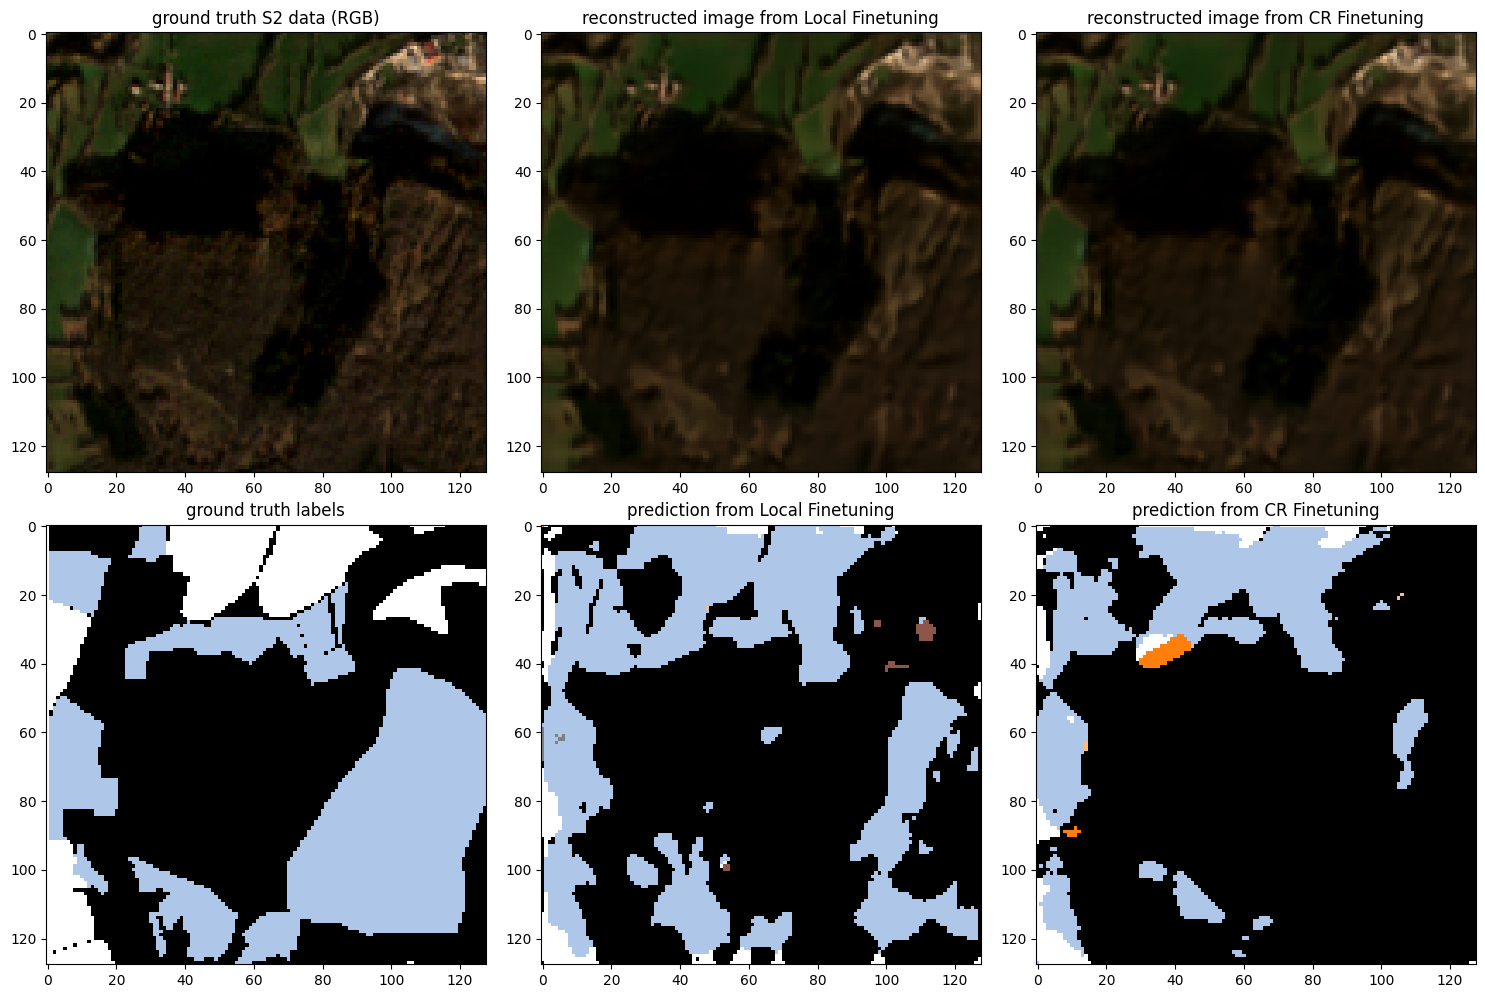

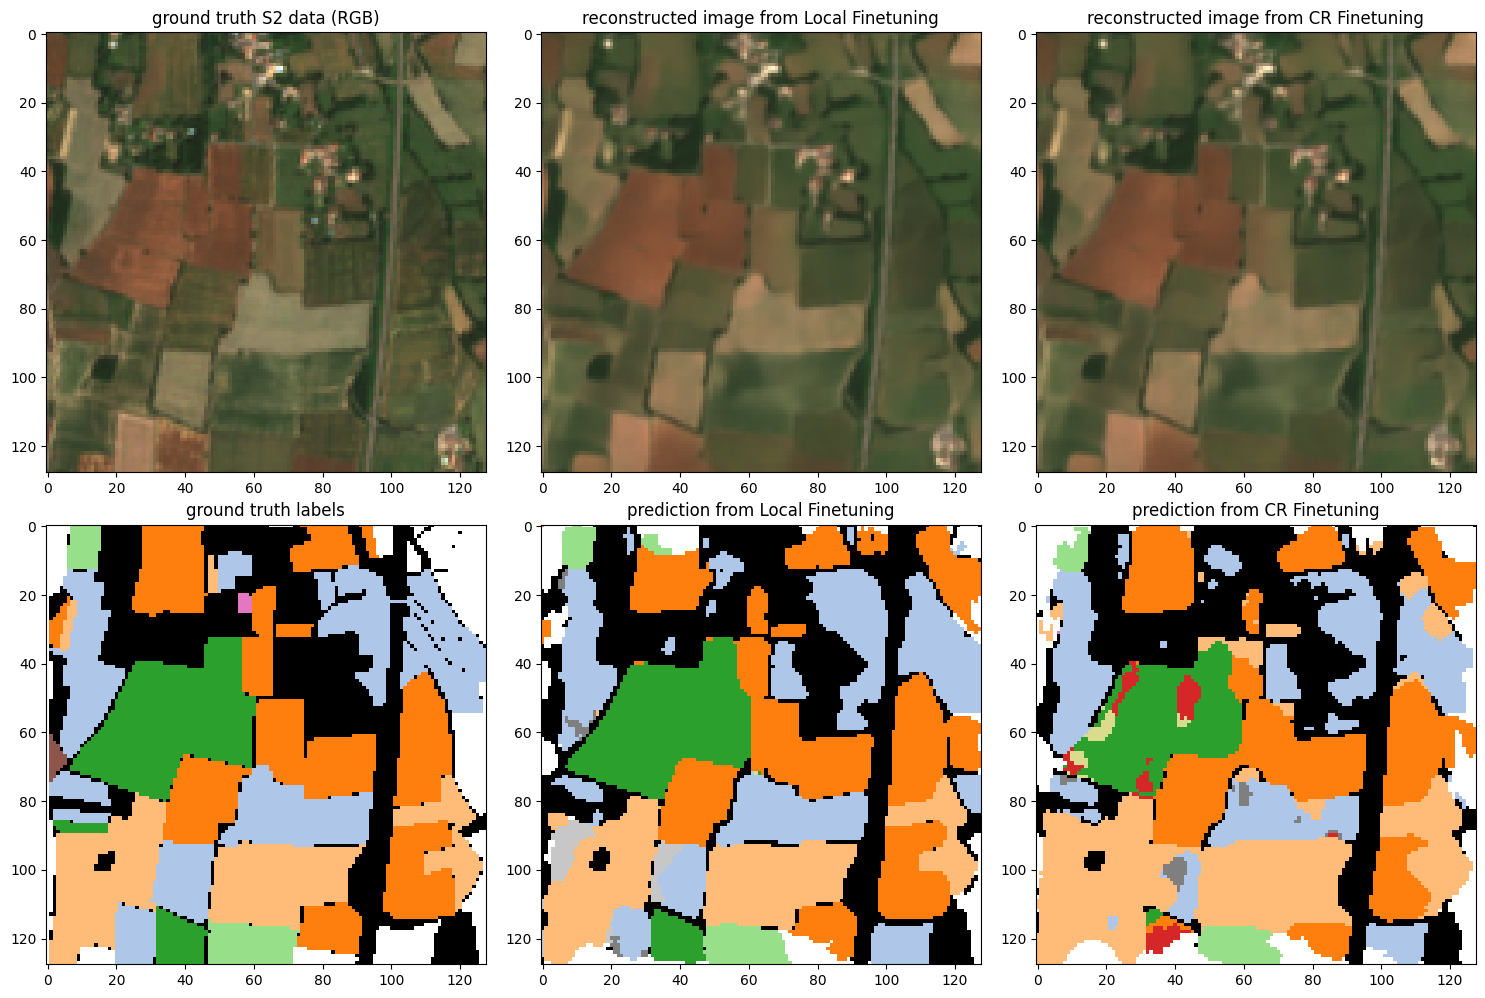

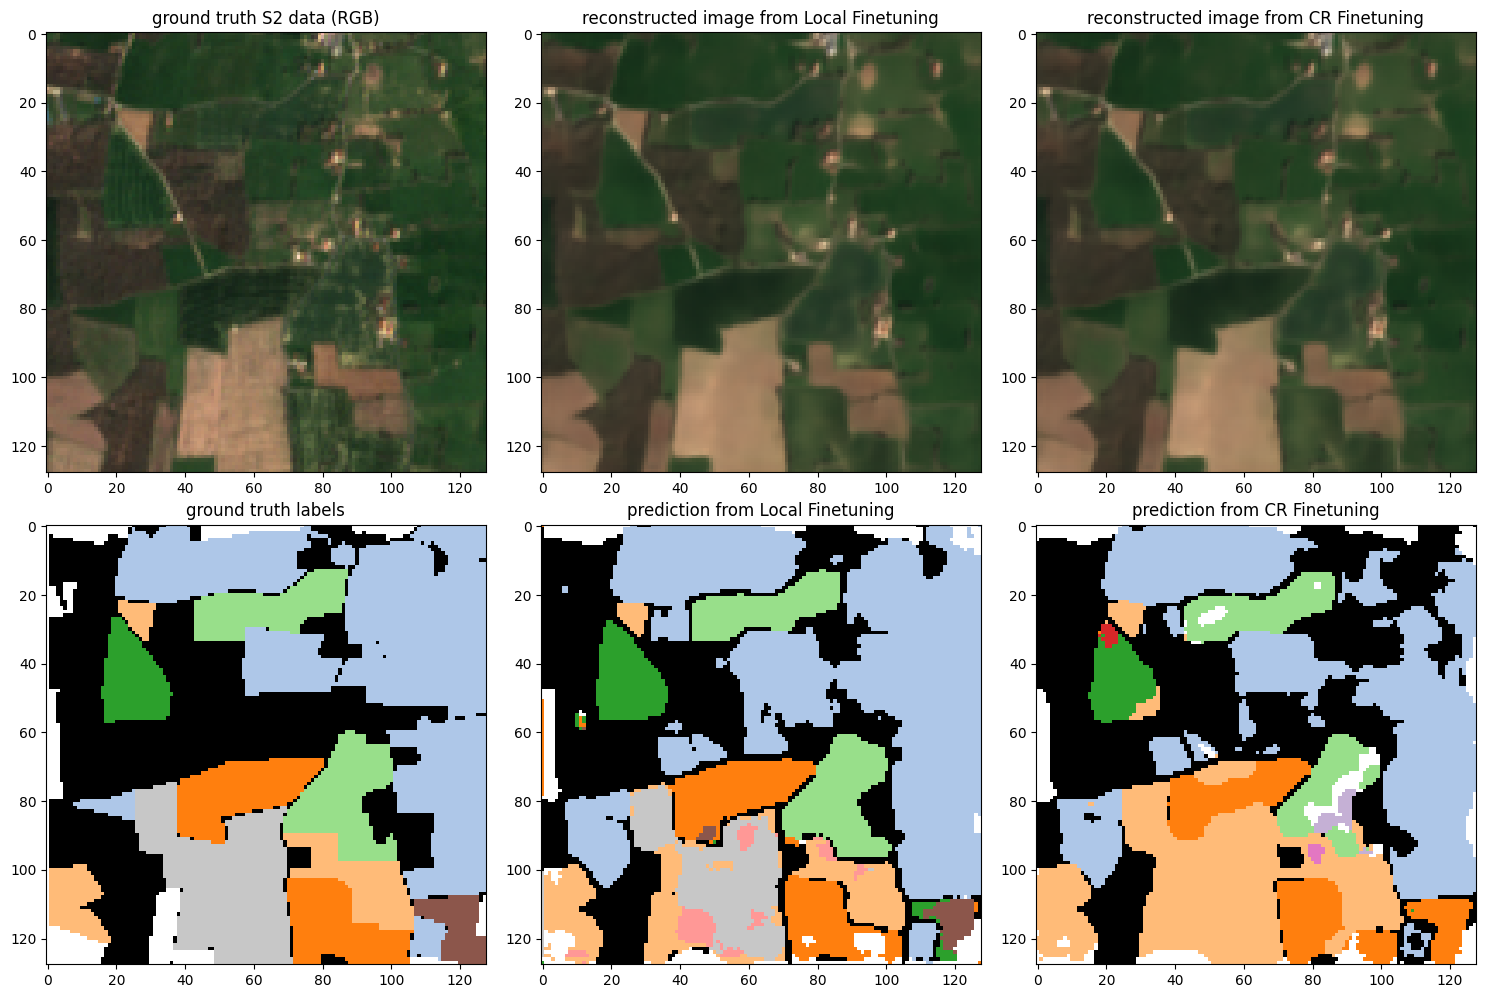

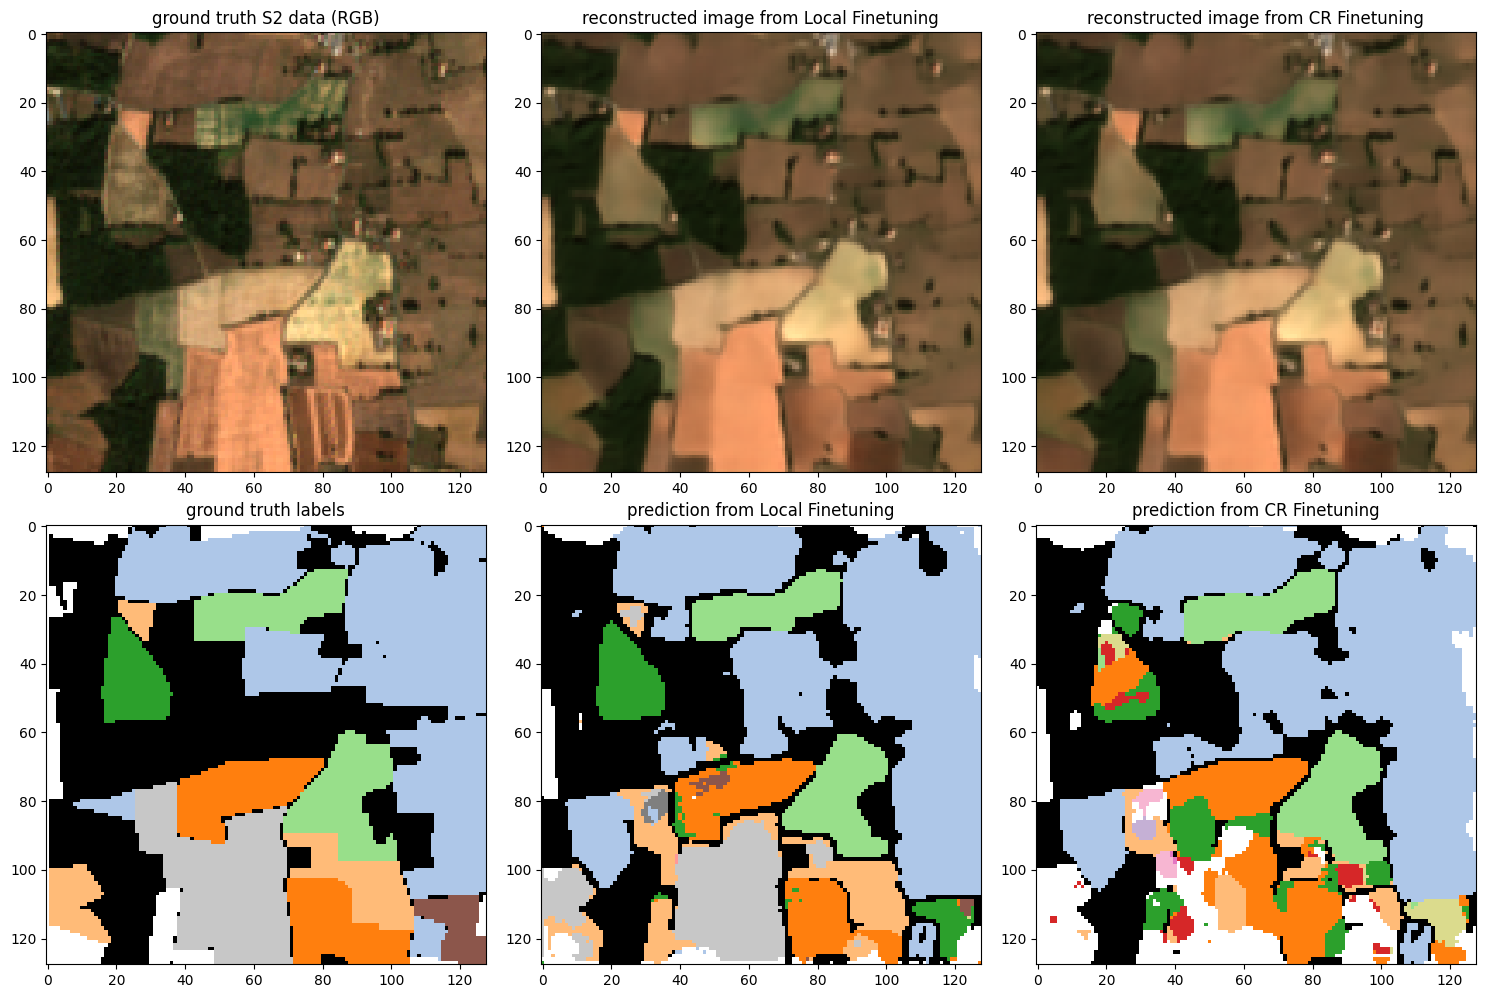

In [94]:
for i in range(10):
    x = torch.Tensor([val_dataset[i]["x_s2"]]).cuda()
    y = torch.Tensor([val_dataset[i]["y_s2"]]).cuda()
    s2data = torch.Tensor(val_dataset[i]["s2data"])
    label = torch.Tensor(val_dataset[i]["label"])
    delta_days = torch.Tensor([val_dataset[i]["delta_days"]]).cuda()
    # print("Inputs:")
    # print(f"  x: {x}")
    # print(f"  y: {y}")
    # print(f"  s2data: {s2data.shape}")
    # print(f"  label: {label.shape}")    
    # print("-" * 30)
    # region_list: {0: ["T31TFJ"], 1: ["T32ULU"], 2: ["T31TFM"], 3: ["T30UXV"]}

    reconstruction, pred = model_finetune(delta_days, x, y, torch.tensor([2]).cuda())
    reconstruction_local, pred_local = model_local_finetune(delta_days, x, y, torch.tensor([2]).cuda())


    fig, ax = plt.subplots(2,3,figsize=(15,10))

    ax[0,0].imshow(s2_to_rgb(s2data.cpu().detach().numpy()).astype(np.float32))
    ax[0,0].set_title("ground truth S2 data (RGB)")
    ax[0,1].imshow(s2_to_rgb(reconstruction_local[0].cpu().detach().numpy()).astype(np.float32))
    ax[0,1].set_title("reconstructed image from Local Finetuning")
    ax[0,2].imshow(s2_to_rgb(reconstruction[0].cpu().detach().numpy()).astype(np.float32))
    ax[0,2].set_title("reconstructed image from CR Finetuning")

    
    
    ax[1,0].imshow(label, vmin=vvmin, vmax=vvmax, cmap=cmap)
    ax[1,0].set_title("ground truth labels")      
    ax[1,1].imshow(np.argmax(pred_local.cpu().detach().numpy(), axis=1)[0], vmin=vvmin, vmax=vvmax, cmap=cmap)
    ax[1,1].set_title("prediction from Local Finetuning")
    ax[1,2].imshow(np.argmax(pred.cpu().detach().numpy(), axis=1)[0], vmin=vvmin, vmax=vvmax, cmap=cmap)
    ax[1,2].set_title("prediction from CR Finetuning")
    
    plt.tight_layout()
    plt.show()  